In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df=pd.read_csv('INvideos.csv')
df.head(3)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...


In [9]:
df.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [91]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [93]:
df.shape

(32562, 16)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32562 entries, 0 to 37330
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                32562 non-null  object
 1   trending_date           32562 non-null  object
 2   title                   32562 non-null  object
 3   channel_title           32562 non-null  object
 4   category_id             32562 non-null  int64 
 5   publish_time            32562 non-null  object
 6   tags                    32562 non-null  object
 7   views                   32562 non-null  int64 
 8   likes                   32562 non-null  int64 
 9   dislikes                32562 non-null  int64 
 10  comment_count           32562 non-null  int64 
 11  thumbnail_link          32562 non-null  object
 12  comments_disabled       32562 non-null  bool  
 13  ratings_disabled        32562 non-null  bool  
 14  video_error_or_removed  32562 non-null  bool  
 15  descrip

In [95]:
df['category_id'] = df['category_id'].astype(int)

In [96]:
df['category_id'].unique()
df['category_id'].value_counts()


,count
category_id,
24,14530
25,4646
10,3291
23,2949
22,2239
1,1455
27,1120
26,794
17,631


In [98]:
df['channel_title'].unique()
df['channel_title'].value_counts()


,count
channel_title,
VikatanTV,208
SAB TV,206
etvteluguindia,205
ETV Plus India,204
Flowers Comedy,202
...,...
ArkivaShqip,1
Knews,1
We Are A Sambavam : The Malayalam Comedy Channel,1


In [99]:
df['title'].unique()
df['title'].value_counts()


,count
title,
Nandhini | Today @ 9 pm | Sun TV,15
Mission: Impossible - Fallout (2018) - Official Trailer - Paramount Pictures,14
Sanju | Official Teaser | Ranbir Kapoor | Rajkumar Hirani,13
Kasthooriman || General Promo || Mon to Sat at 8:30 PM || Asianet,12
School Ke Wo Din - Amit Bhadana,11
...,...
It’s not you. Phones are designed to be addicting.,1
"David Guetta, Martin Garrix & Brooks - Like I Do (Lyric Video)",1
Arundhathi | അരുന്ധതി | Flowers | Ep# 39,1


In [21]:
columns_to_convert = ['views', 'likes', 'dislikes', 'comment_count','like_view_ratio']

for col in columns_to_convert:
    df[col] = df[col].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17727 entries, 0 to 18330
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                17727 non-null  object
 1   trending_date           17727 non-null  object
 2   title                   17727 non-null  object
 3   channel_title           17727 non-null  object
 4   category_id             17727 non-null  int64 
 5   publish_time            17727 non-null  object
 6   tags                    17727 non-null  object
 7   views                   17727 non-null  int64 
 8   likes                   17727 non-null  int64 
 9   dislikes                17727 non-null  int64 
 10  comment_count           17727 non-null  int64 
 11  thumbnail_link          17727 non-null  object
 12  comments_disabled       17727 non-null  object
 13  ratings_disabled        17727 non-null  object
 14  video_error_or_removed  17727 non-null  object
 15  descrip

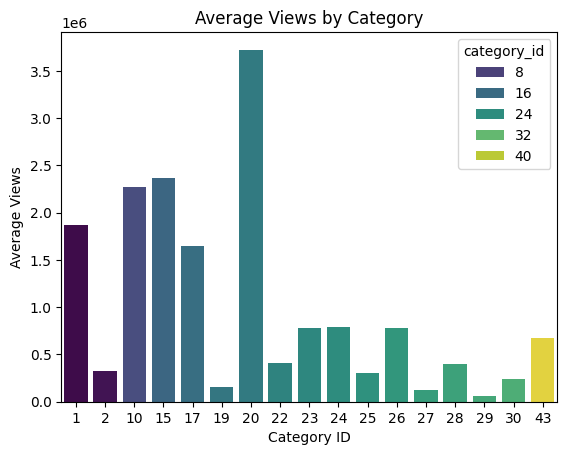

In [33]:
cat_views = df.groupby("category_id")["views"].mean().sort_values(ascending=False)

# Convert the Series to a DataFrame to use 'hue' effectively
cat_views_df = cat_views.reset_index()

sns.barplot(x='category_id', y='views', data=cat_views_df, hue='category_id', palette='viridis', legend=True)
plt.title("Average Views by Category")
plt.xlabel("Category ID")
plt.ylabel("Average Views")
plt.show()

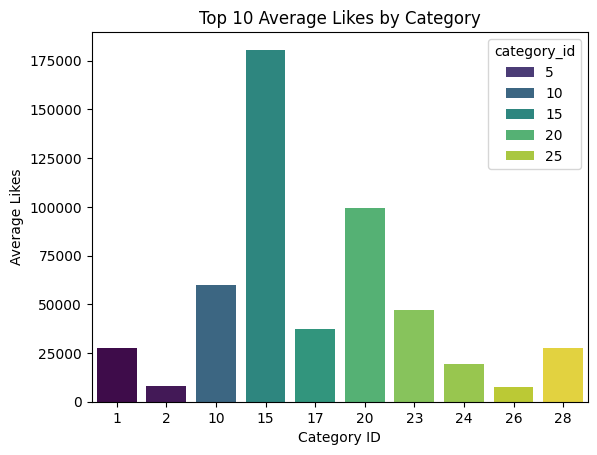

In [32]:
avg_likes = df.groupby("category_id")["likes"].mean().sort_values(ascending=False)

# Convert the Series to a DataFrame to use 'hue' effectively
avg_likes_df = avg_likes.reset_index()

sns.barplot(x='category_id', y='likes', data=avg_likes_df.head(10), hue='category_id', palette='viridis', legend=True)
plt.title("Top 10 Average Likes by Category")
plt.xlabel("Category ID")
plt.ylabel("Average Likes")
plt.show()

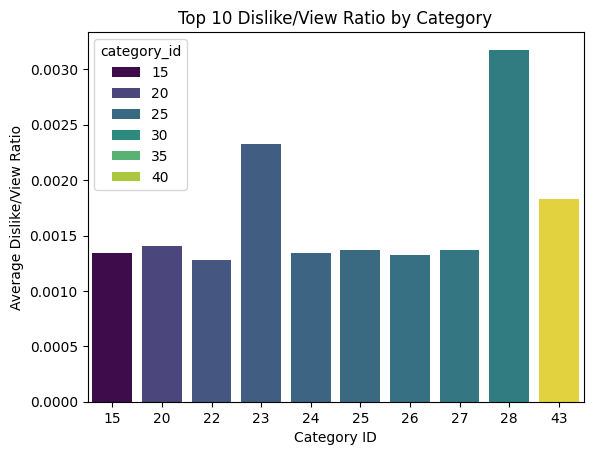

In [35]:
df["dislike_view_ratio"] = df["dislikes"] / df["views"].replace(0, 1)

rat_dislike = df.groupby("category_id")["dislike_view_ratio"].mean().sort_values(ascending=False)

rat_dislike_df = rat_dislike.reset_index()

sns.barplot(x='category_id', y='dislike_view_ratio', data=rat_dislike_df.head(10), hue='category_id', palette='viridis', legend=True)
plt.title("Top 10 Dislike/View Ratio by Category")
plt.xlabel("Category ID")
plt.ylabel("Average Dislike/View Ratio")
plt.show()

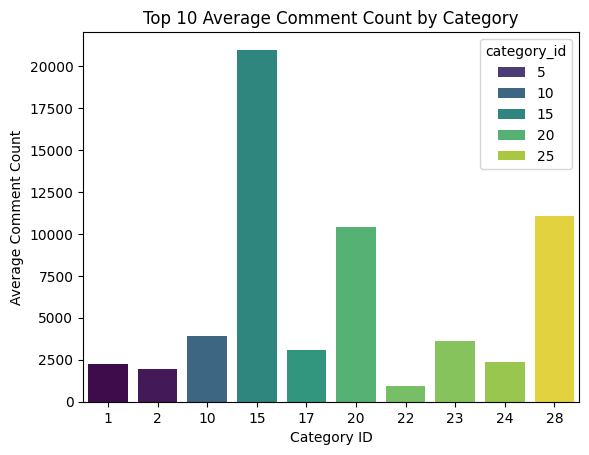

In [37]:
avg_comments = df.groupby("category_id")["comment_count"].mean().sort_values(ascending=False)

# Convert the Series to a DataFrame to use 'hue' effectively
avg_comments_df = avg_comments.reset_index()

sns.barplot(x='category_id', y='comment_count', data=avg_comments_df.head(10), hue='category_id', palette='viridis', legend=True)
plt.title("Top 10 Average Comment Count by Category")
plt.xlabel("Category ID")
plt.ylabel("Average Comment Count")
plt.show()

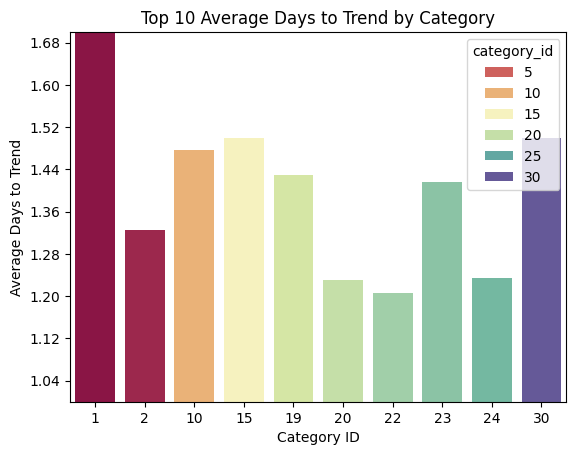

In [65]:
import matplotlib.ticker as ticker

avg_days_to_trend = df.groupby("category_id")["days_to_trend"].mean().sort_values(ascending=False)

# Convert the Series to a DataFrame to use 'hue' effectively and select top 10
avg_days_to_trend_df = avg_days_to_trend.reset_index().head(10)

sns.barplot(x='category_id', y='days_to_trend', data=avg_days_to_trend_df,palette='Spectral',hue='category_id')
plt.title("Top 10 Average Days to Trend by Category")
plt.xlabel("Category ID")
plt.ylabel("Average Days to Trend")
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Force integer ticks on y-axis
plt.ylim(ymin=1.0, ymax=1.7) # Adjust y-axis lower and upper limits
plt.show()

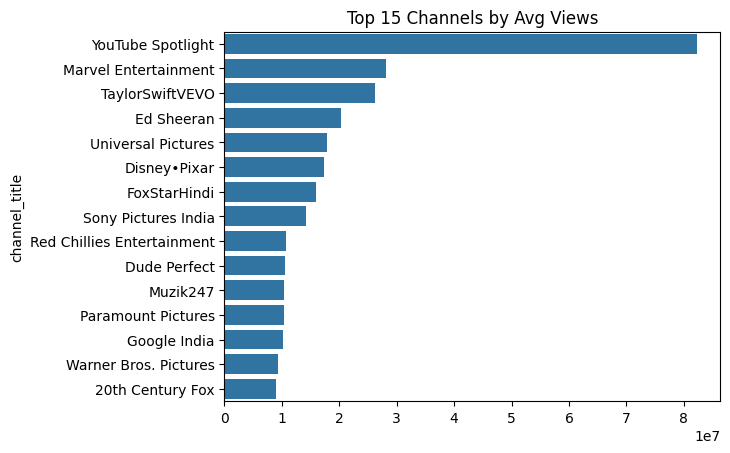

In [66]:
top = df.groupby("channel_title")["views"].mean().sort_values(ascending=False).head(15)

sns.barplot(y=top.index, x=top.values)
plt.title("Top 15 Channels by Avg Views")
plt.show()


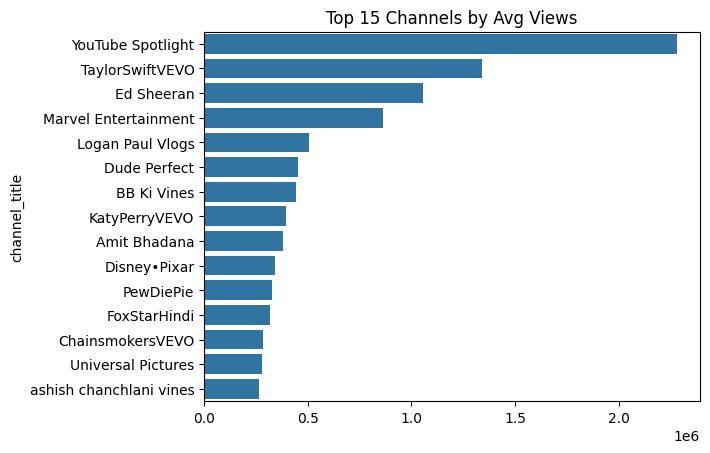

In [68]:
top = df.groupby("channel_title")["likes"].mean().sort_values(ascending=False).head(15)

sns.barplot(y=top.index, x=top.values)
plt.title("Top 15 Channels by Avg Views")
plt.show()


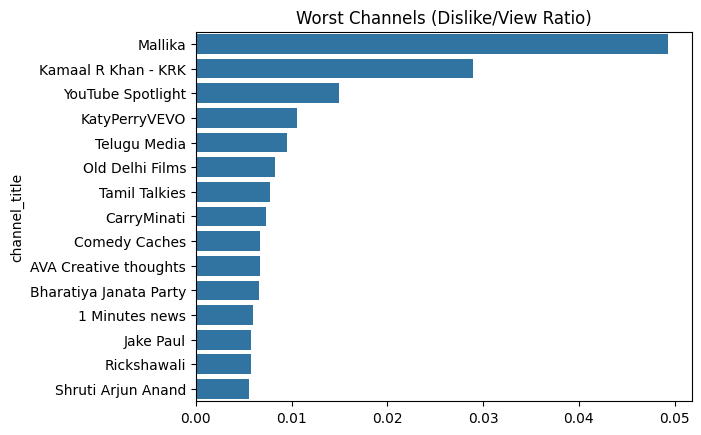

In [69]:
top_bad = df.groupby("channel_title")["dislike_view_ratio"].mean().sort_values(ascending=False).head(15)

sns.barplot(y=top_bad.index, x=top_bad.values)
plt.title("Worst Channels (Dislike/View Ratio)")
plt.show()


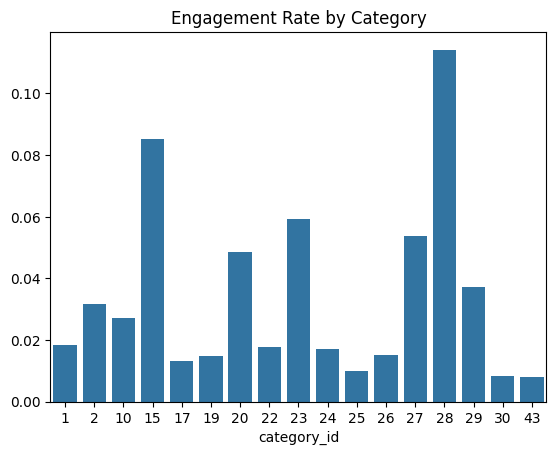

In [70]:
df["engagement"] = (df["likes"] + df["comment_count"]) / df["views"].replace(0,1)

eng = df.groupby("category_id")["engagement"].mean()

sns.barplot(x=eng.index, y=eng.values)
plt.title("Engagement Rate by Category")
plt.show()


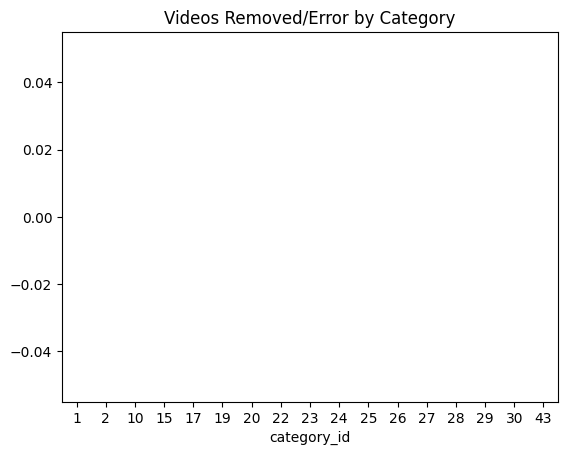

In [72]:
rem = df.groupby("category_id")["video_error_or_removed"].sum()

sns.barplot(x=rem.index, y=rem.values)
plt.title("Videos Removed/Error by Category")
plt.show()


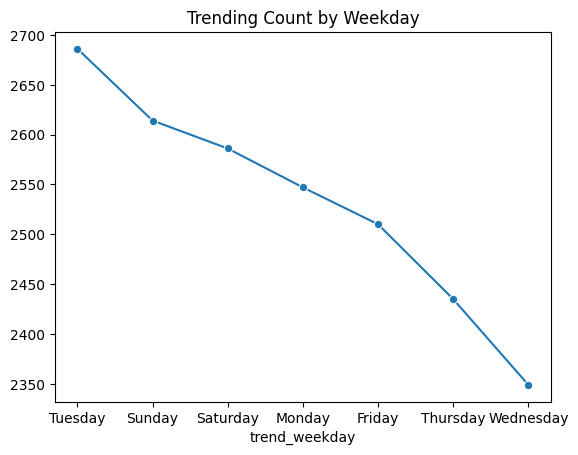

In [73]:
df["trend_weekday"] = df["trending_date"].dt.day_name()

day_count = df["trend_weekday"].value_counts()

sns.lineplot(x=day_count.index, y=day_count.values, marker="o")
plt.title("Trending Count by Weekday")
plt.show()


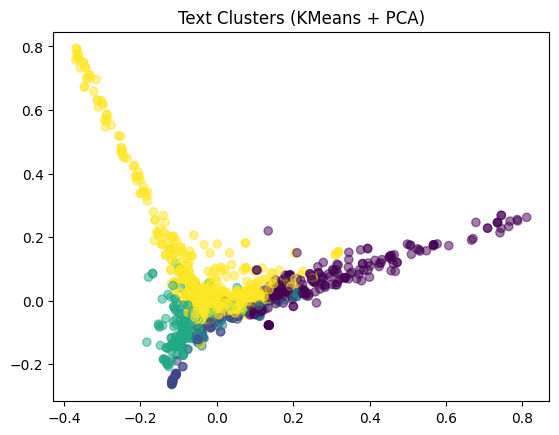

In [76]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df["text"] = df["title"].fillna("") + " " + df["tags"].fillna("")

vec = TfidfVectorizer(max_features=2000, stop_words="english")
X = vec.fit_transform(df["text"])

kmeans = KMeans(n_clusters=6)
labels = kmeans.fit_predict(X)

df["cluster"] = labels

# PCA plot
sample = df.sample(2000)
Xp = PCA(n_components=2).fit_transform(vec.transform(sample["text"]).toarray())

plt.scatter(Xp[:,0], Xp[:,1], c=sample["cluster"], alpha=0.5)
plt.title("Text Clusters (KMeans + PCA)")
plt.show()


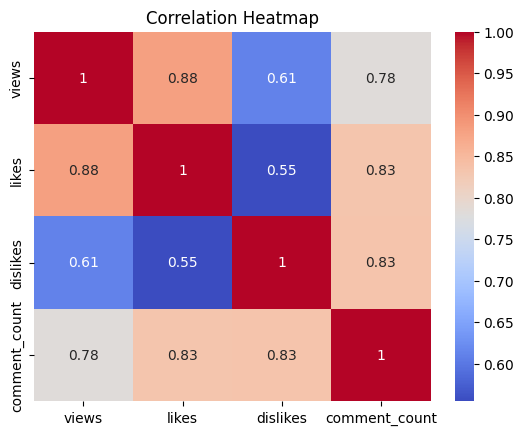

In [78]:
num_cols = ["views","likes","dislikes","comment_count"]

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [79]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 17727 entries, 0 to 18330
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   video_id                17727 non-null  object        
 1   trending_date           17727 non-null  datetime64[ns]
 2   title                   17727 non-null  object        
 3   channel_title           17727 non-null  object        
 4   category_id             17727 non-null  int64         
 5   publish_time            17727 non-null  datetime64[ns]
 6   tags                    17727 non-null  object        
 7   views                   17727 non-null  int64         
 8   likes                   17727 non-null  int64         
 9   dislikes                17727 non-null  int64         
 10  comment_count           17727 non-null  int64         
 11  thumbnail_link          17727 non-null  object        
 12  comments_disabled       17727 non-null  object     

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,description,like_view_ratio,dislike_view_ratio,days_to_trend,engagement,trend_weekday,pub_weekday,pub_hour,text,cluster
0,kzwfHumJyYc,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12 12:20:39,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,...,Presenting Sharry Mann latest Punjabi Song Cu...,0.030982,0.000728,1,0.031786,Tuesday,Sunday,12,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,5
1,zUZ1z7FwLc8,2017-11-14,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13 05:43:56,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,...,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",0.001246,0.001532,0,0.001246,Tuesday,Monday,5,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",0
2,10L1hZ9qa58,2017-11-14,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12 15:48:08,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,...,Watch Stylish Star Allu Arjun @ ChaySam Weddin...,0.004243,0.000513,1,0.004557,Tuesday,Sunday,15,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,5
3,N1vE8iiEg64,2017-11-14,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12 07:08:48,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,...,This video showcases the difference between pe...,0.056614,0.001307,1,0.058774,Tuesday,Sunday,7,"Eruma Saani | Tamil vs English Eruma Saani|""Ta...",5
4,kJzGH0PVQHQ,2017-11-14,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13 01:14:16,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,...,why Samantha became EMOTIONAL @ Samantha naga ...,0.001060,0.000631,0,0.001203,Tuesday,Monday,1,why Samantha became EMOTIONAL @ Samantha naga ...,5


In [85]:
df.describe()

,trending_date,category_id,publish_time,views,likes,dislikes,comment_count,like_view_ratio,dislike_view_ratio,days_to_trend,engagement,pub_hour,cluster
count,17727,17727.000000,17727,1.772700e+04,1.772700e+04,1.772700e+04,17727.000000,17727.000000,17727.000000,17727.000000,17727.000000,17727.000000,17727.000000
mean,2018-01-01 17:50:23.658825472,21.672928,2017-12-30 23:32:53.304958720,8.563266e+05,2.188514e+04,1.491033e+03,2252.267953,0.020835,0.001425,1.229086,0.023422,10.730355,3.806397
min,2017-11-14 00:00:00,1.000000,2017-05-27 20:27:30,4.641000e+03,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,2017-12-08 00:00:00,23.000000,2017-12-05 13:59:48.500000,9.539900e+04,6.270000e+02,8.000000e+01,54.000000,0.004017,0.000614,0.000000,0.004577,7.000000,3.000000
50%,2018-01-01 00:00:00,24.000000,2017-12-29 18:30:45,2.252390e+05,2.174000e+03,2.410000e+02,240.000000,0.008688,0.000976,1.000000,0.010038,11.000000,5.000000
75%,2018-01-26 00:00:00,24.000000,2018-01-24 16:30:01,6.094960e+05,8.749500e+03,7.660000e+02,900.500000,0.025549,0.001667,2.000000,0.028262,14.000000,5.000000
max,2018-02-23 00:00:00,43.000000,2018-02-22 13:42:32,1.254322e+08,2.912710e+06,1.545017e+06,827755.000000,0.364964,0.064109,220.000000,0.689328,23.000000,5.000000
std,NaN,6.546493,NaN,3.176553e+06,9.693477e+04,2.246193e+04,16745.741073,0.028706,0.001768,2.702090,0.033960,5.023869,1.740070


In [89]:
df.to_csv('youtube channels records analysis.csv', index=False)

# **Tasks short summary**
clean the data by dropping null values
and duplicate rows, and converting `category_id`, `views`, `likes`, `dislikes`, and `comment_count` columns to appropriate data types. Engineer new features including `days_to_trend` (calculated from `trending_date` and `publish_time` after converting them to datetime objects), `trend_weekday`, `pub_hour`, `like_view_ratio`, `dislike_view_ratio`, and an `engagement` score. Finally, visualize the top categories based on average views, likes, and comment counts, and analyze the average days it takes for videos to trend within each category.

**## Data Preparation and Cleaning**
Loaded the dataset, handled missing values by dropping them, removed duplicate entries, and converted relevant columns (like `category_id`, `views`, `likes`, `dislikes`, `comment_count`) to appropriate data types for analysis.


**## Feature Engineering**
Created new insightful features: calculated days_to_trend by converting date columns to datetime objects, extracted trend_weekday and pub_hour, and computed like_view_ratio, dislike_view_ratio, and an overall engagement score for videos.


**## Category Performance Analysis**
Visualize the top categories based on average views, likes, and comment counts, and analyze the average days it takes for videos to trend within each category.



### **Data Analysis Key Findings**
*   Data preparation and cleaning, including loading the dataset, handling missing values, removing duplicates, and converting data types for `category_id`, `views`, `likes`, `dislikes`, and `comment_count`, were already completed prior to this analysis phase.
*   Feature engineering, which involved creating `days_to_trend`, `trend_weekday`, `pub_hour`, `like_view_ratio`, `dislike_view_ratio`, and `engagement` score, was also pre-completed.
*   No new code execution was performed for either data preparation or feature engineering steps, as all requirements were reported as pre-fulfilled.

**### Insights or Next Steps**
*   The next logical step is to proceed with the visualization and analysis of top categories based on average views, likes, and comment counts, and to analyze the average days to trend for videos within each category, utilizing the prepared data and engineered features.
*   Ensure the integrity and correctness of the pre-processed data and engineered features before commencing the analysis to avoid erroneous conclusions.
